# Normal Distribution

### PDF - Probabilty distribution function
- We calculate this when we don't know about N so we use certain function where we put mean and std and xi to calculate pdf for that xi
### Likelihood 
- Product of all P.D.F from 1 to n is Likelihood

### Log likelihood
- But if we take product and suppose somewhere we are getting zero or close to zero p.d.f, then entire likelihood become zero.
- So, we take log-likelihood

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
true_mean = 10
true_std = 5

In [38]:
normal_distribution = np.random.normal(loc=true_mean, scale=true_std,size=10000)
normal_distribution

array([18.33013068,  2.18293838,  6.17252581, ...,  7.80345079,
       13.67006357, 11.38446717])

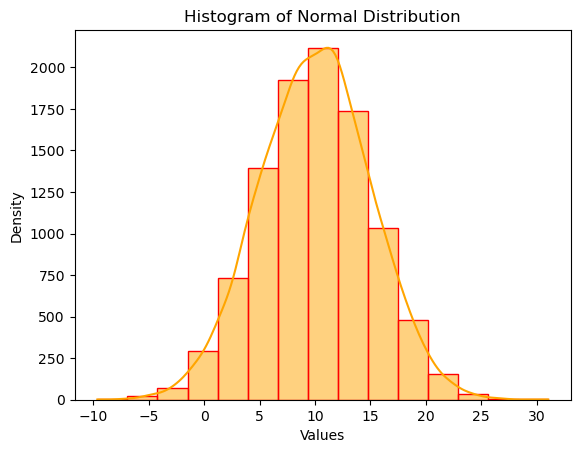

In [42]:
sns.histplot(normal_distribution, bins=15, kde=True, color='orange', edgecolor='red')
plt.title("Histogram of Normal Distribution")
plt.xlabel('Values')
plt.ylabel('Density')
plt.show()

# MLE Derivation for Normal Distribution $N(\mu, \sigma^2)$

### 1. The Likelihood Function
Given $n$ independent and identically distributed (i.i.d.) observations $x_1, x_2, \dots, x_n$, the joint Probability Density Function (PDF) is the product of individual PDFs:

$$L(\mu, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right)$$

### 2. The Log-Likelihood Function
Taking the natural logarithm ($\ln$) simplifies the product into a sum and removes the exponent:

$$\ell(\mu, \sigma^2) = \ln \left[ (2\pi\sigma^2)^{-n/2} \exp\left( -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2 \right) \right]$$

$$\ell(\mu, \sigma^2) = -\frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2$$

---

### 3. Estimating $\mu$ (The Mean)
Take the partial derivative of $\ell$ with respect to $\mu$ and set it to zero:

$$\frac{\partial \ell}{\partial \mu} = \frac{1}{\sigma^2} \sum_{i=1}^{n} (x_i - \mu) = 0$$

Solve for $\mu$:
$$\sum_{i=1}^{n} x_i - n\mu = 0 \implies \sum_{i=1}^{n} x_i = n\mu$$
$$\hat{\mu}_{MLE} = \frac{1}{n} \sum_{i=1}^{n} x_i = \bar{x}$$

---

### 4. Estimating $\sigma^2$ (The Variance)
Take the partial derivative with respect to $\sigma^2$ and set it to zero:

$$\frac{\partial \ell}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2} \sum_{i=1}^{n} (x_i - \mu)^2 = 0$$

Multiply by $2(\sigma^2)^2$:
$$-n\sigma^2 + \sum_{i=1}^{n} (x_i - \mu)^2 = 0$$

Solve for $\sigma^2$:
$$\hat{\sigma}^2_{MLE} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

---

### Summary
* **MLE for Mean:** $\hat{\mu} = \text{sample mean}$
* **MLE for Variance:** $\hat{\sigma}^2 = \text{biased sample variance (divided by } n\text{)}$


In [43]:
def normal_log_likelihood(x, mu, sigma):
    n = len(x)
    # The natural log of the constant and variance part
    term1 = - (n / 2) * np.log(2 * np.pi * sigma**2)
    # The sum of squared residuals part
    term2 = - (1 / (2 * sigma**2)) * np.sum((x - mu)**2)
    return term1 + term2

In [64]:
theta = [-5,0,5,10,15,20,25,30]
all_log_likelihoood = []
for param in theta:
    all_log_likelihoood.append(normal_log_likelihood(x=normal_distribution, mu=param, sigma=true_std))

/var/folders/tm/qlbspt1n3rjf7jq7m0k78fhh0000gn/T/ipykernel_26988/131111623.py:1: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(theta,all_log_likelihoood, 'r-o', linestyle = 'dashed',)


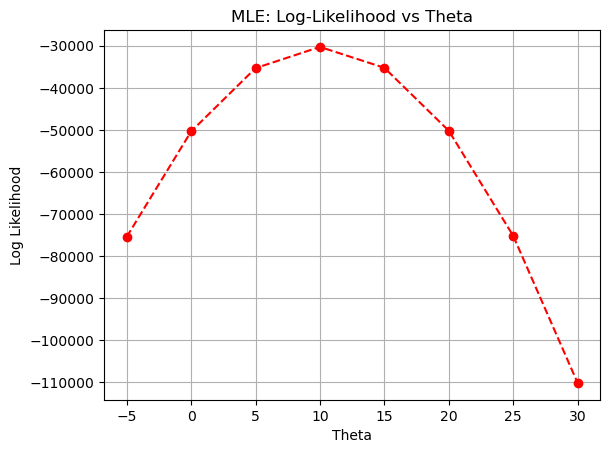

In [65]:
plt.plot(theta,all_log_likelihoood, 'r-o', linestyle = 'dashed',)
plt.xlabel("Theta")
plt.ylabel("Log Likelihood")
plt.title("MLE: Log-Likelihood vs Theta")
plt.grid(True)
plt.show()

In [66]:
print("All Theta:", theta)

print("All Log-likelihood:", all_log_likelihoood)

All Theta: [-5, 0, 5, 10, 15, 20, 25, 30]
All Log-likelihood: [-75402.80953357436, -50360.730208247216, -35318.65088292007, -30276.571557592924, -35234.49223226578, -50192.41290693864, -75150.33358161148, -110108.25425628433]


In [67]:
optimal_theta = theta[np.argmax(all_log_likelihoood)]
print("Optimal theta at which log-likelihood is maximum:", optimal_theta)

Optimal theta at which log-likelihood is maximum: 10
